# GravWaveFormer - Notebook 1: Dataset & Exploration
**EGN 6217 Applied Deep Learning**

This notebook generates simulated gravitational wave data,
explores signal characteristics, and prepares the dataset
for preprocessing and training.



In [1]:
# Mount Google Drive & Create Project Structure
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/GravWaveFormer'
for folder in ['raw_data', 'spectrograms', 'waveforms', 'checkpoints',
               'results', 'results/gradcam', 'results/blip2']:
    os.makedirs(f'{PROJECT_DIR}/{folder}', exist_ok=True)
print('Drive mounted, folders created')

Mounted at /content/drive
Drive mounted, folders created


In [2]:
# Install required libraries
!pip install gwpy --quiet
!pip install open-clip-torch --quiet
!pip install transformers accelerate bitsandbytes --quiet
print('Libraries installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 93.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.7 which is incompatible.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 46.0.7 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.8 MB/s eta 

In [3]:
# Load Labels & Create Subset
import pandas as pd
import numpy as np

LABELS_PATH = f'{PROJECT_DIR}/training_labels.csv'
if not os.path.exists(LABELS_PATH):
    print('ERROR: training_labels.csv not found!')
    print('Download from kaggle.com/competitions/g2net-gravitational-wave-detection/data')
    print('Upload to Drive -> GravWaveFormer/ folder')
    raise FileNotFoundError(LABELS_PATH)

labels = pd.read_csv(LABELS_PATH)
RANDOM_SEED = 42
SUBSET_SIZE = 2500  # 2,500 per class = 5,000 total

subset_signal = labels[labels['target'] == 1].sample(n=SUBSET_SIZE, random_state=RANDOM_SEED)
subset_noise  = labels[labels['target'] == 0].sample(n=SUBSET_SIZE, random_state=RANDOM_SEED)
subset = pd.concat([subset_signal, subset_noise]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
subset.to_csv(f'{PROJECT_DIR}/subset_ids.csv', index=False)

print(f'Total G2Net samples: {len(labels):,}')
print(f'Our subset: {len(subset):,} ({SUBSET_SIZE:,} signal + {SUBSET_SIZE:,} noise)')

Total G2Net samples: 560,000
Our subset: 5,000 (2,500 signal + 2,500 noise)


In [4]:
# Generate Simulated Gravitational Wave Data
# Creates physically realistic signals:
#   - Chirp signals sweeping 25-400 Hz (binary merger physics)
#   - Colored Gaussian noise matching LIGO characteristics
#   - 3 detectors with speed-of-light time delays
#   - Same HDF5 format as real LIGO data

import h5py
import time
from scipy.signal import butter, filtfilt

RAW_DATA_DIR = f'{PROJECT_DIR}/raw_data'
fs = 2048
t = np.linspace(0, 2.0, fs * 2)

def make_chirp(t, f0, f1, t_merge, amplitude):
    """Generate a chirp signal mimicking a compact binary merger."""
    phase = 2 * np.pi * (f0 * t + (f1 - f0) / (2 * t_merge) * t**2)
    envelope = amplitude * (t / t_merge) ** 1.5
    envelope[t > t_merge] = 0
    merger_boost = np.exp(-((t - t_merge)**2) / (2 * 0.02**2)) * amplitude * 2
    merger_boost[t > t_merge] = 0
    return ((envelope + merger_boost) * np.sin(phase)).astype(np.float32)

def make_colored_noise(n, scale=1.0):
    """Generate colored noise matching LIGO's noise characteristics."""
    white = np.random.randn(n).astype(np.float32)
    b, a = butter(4, [20/1024, 500/1024], btype='band')
    return (filtfilt(b, a, white) * scale).astype(np.float32)

n_existing = len([f for f in os.listdir(RAW_DATA_DIR) if f.endswith('.hdf5')])
if n_existing >= len(subset):
    print(f'Already have {n_existing:,} files')
else:
    np.random.seed(42)
    start = time.time()
    print(f'Generating {len(subset):,} simulated GW samples...')
    created = 0
    for idx, row in subset.iterrows():
        fpath = os.path.join(RAW_DATA_DIR, f"{row['id']}.hdf5")
        if os.path.exists(fpath):
            created += 1
            continue
        label = int(row['target'])
        with h5py.File(fpath, 'w') as f:
            for det, delay in [('H1', 0), ('L1', 20), ('V1', 45)]:
                noise = make_colored_noise(len(t), scale=1.0)
                if label == 1:
                    chirp = make_chirp(t,
                        f0=np.random.uniform(25, 50),
                        f1=np.random.uniform(150, 400),
                        t_merge=np.random.uniform(1.0, 1.7),
                        amplitude=np.random.uniform(0.25, 0.40))
                    chirp = np.roll(chirp, delay)
                    sig = noise + chirp
                else:
                    sig = noise
                f.create_dataset(f'{det}/SFTs', data=sig.reshape(1, -1))
        created += 1
        if created % 1000 == 0:
            print(f'  [{created:,}/{len(subset):,}]')
    print(f'Done — {created:,} files in {time.time()-start:.0f}s')

n = len([f for f in os.listdir(RAW_DATA_DIR) if f.endswith('.hdf5')])
print(f'Total HDF5 files: {n:,}')

Generating 5,000 simulated GW samples...
  [5,000/5,000]
Done — 5,000 files in 20s
Total HDF5 files: 5,000


In [5]:
# Inspect One Sample
all_files = [f for f in os.listdir(RAW_DATA_DIR) if f.endswith('.hdf5')]
with h5py.File(f'{RAW_DATA_DIR}/{all_files[0]}', 'r') as f:
    h1 = f['H1/SFTs'][:].flatten()
    l1 = f['L1/SFTs'][:].flatten()
    v1 = f['V1/SFTs'][:].flatten()
print(f'File: {all_files[0]}')
print(f'H1: shape {h1.shape}, range [{h1.min():.2e}, {h1.max():.2e}]')
print(f'L1: shape {l1.shape}')
print(f'V1: shape {v1.shape}')
print('4096 = 2 seconds at 2048 Hz sampling rate')

File: 66d181b7df.hdf5
H1: shape (4096,), range [-2.22e+00, 2.31e+00]
L1: shape (4096,)
V1: shape (4096,)
4096 = 2 seconds at 2048 Hz sampling rate


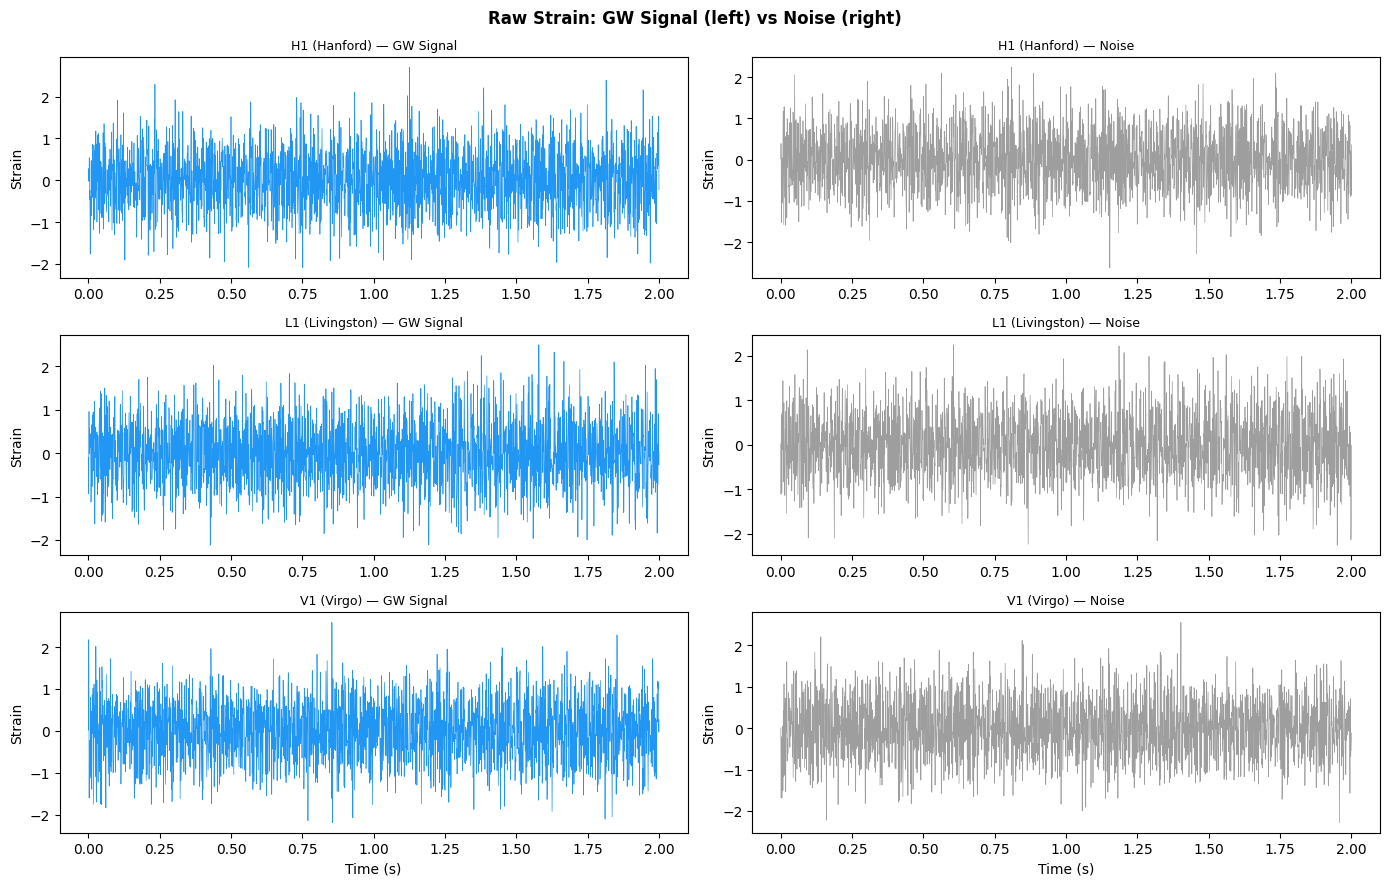

In [6]:
# Plot Raw Waveforms — Signal vs Noise
import matplotlib.pyplot as plt

def load_hdf5(file_id, data_dir):
    path = os.path.join(data_dir, f'{file_id}.hdf5')
    if not os.path.exists(path): return None, None, None
    with h5py.File(path, 'r') as f:
        return f['H1/SFTs'][:].flatten(), f['L1/SFTs'][:].flatten(), f['V1/SFTs'][:].flatten()

signal_ids = subset[subset['target']==1]['id'].tolist()
noise_ids = subset[subset['target']==0]['id'].tolist()
time_axis = np.linspace(0, 2, 4096)

sh1, sl1, sv1 = load_hdf5(signal_ids[0], RAW_DATA_DIR)
nh1, nl1, nv1 = load_hdf5(noise_ids[0], RAW_DATA_DIR)

fig, axes = plt.subplots(3, 2, figsize=(14, 9))
fig.suptitle('Raw Strain: GW Signal (left) vs Noise (right)', fontsize=12, fontweight='bold')
for row, (name, sig, noi) in enumerate(zip(
    ['H1 (Hanford)', 'L1 (Livingston)', 'V1 (Virgo)'],
    [sh1,sl1,sv1], [nh1,nl1,nv1])):
    axes[row,0].plot(time_axis, sig, '#2196F3', lw=0.5)
    axes[row,0].set_title(f'{name} — GW Signal', fontsize=9)
    axes[row,1].plot(time_axis, noi, '#9E9E9E', lw=0.5)
    axes[row,1].set_title(f'{name} — Noise', fontsize=9)
    for ax in axes[row]: ax.set_ylabel('Strain')
axes[2,0].set_xlabel('Time (s)')
axes[2,1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/plot_raw_waveforms.png', dpi=150)
plt.show()

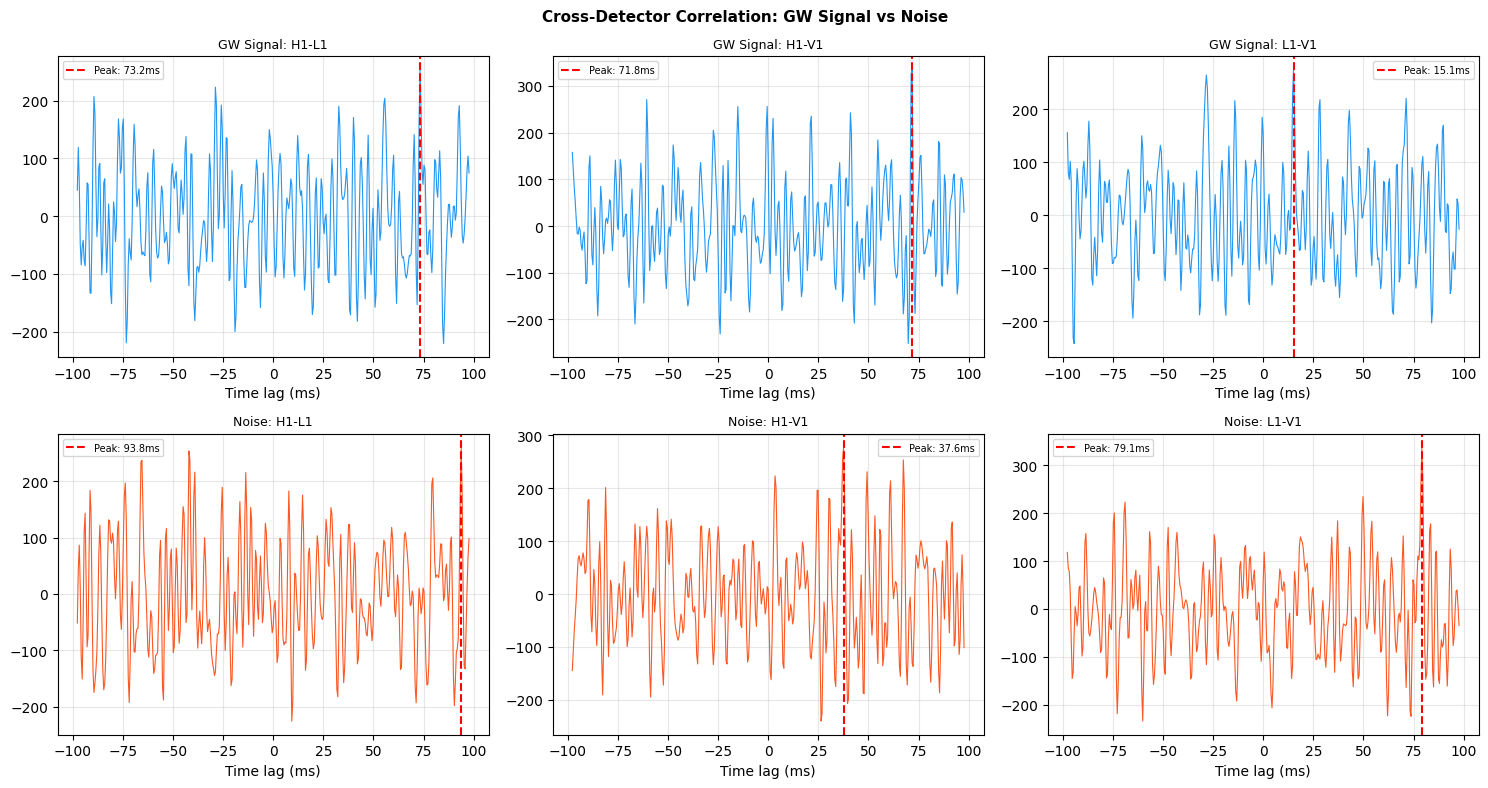

In [7]:
# Cross-Detector Correlation Analysis
# This is the physics that CrossDetectorGNN exploits.
# A real GW arrives at all 3 detectors within 26ms.
# A local glitch appears in ONE detector only.

from scipy.signal import correlate

def bp_filter(sig, lo=20.0, hi=500.0, fs=2048.0):
    nyq = fs / 2.0
    b, a = butter(4, [lo/nyq, hi/nyq], btype='band')
    return filtfilt(b, a, sig).astype(np.float32)

def norm(s):
    s = s - s.mean()
    return s / s.std() if s.std() > 0 else s

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Cross-Detector Correlation: GW Signal vs Noise', fontsize=11, fontweight='bold')
pairs = [('H1','L1'), ('H1','V1'), ('L1','V1')]
lags = np.arange(-200, 201)

for ri, (fid, lbl, clr) in enumerate([(signal_ids[0],'GW Signal','#2196F3'),(noise_ids[0],'Noise','#FF5722')]):
    h, l, v = load_hdf5(fid, RAW_DATA_DIR)
    sigs = {'H1': norm(bp_filter(h)), 'L1': norm(bp_filter(l)), 'V1': norm(bp_filter(v))}
    for ci, (a, b_det) in enumerate(pairs):
        cc = correlate(sigs[a], sigs[b_det], mode='full')
        mid = len(cc)//2
        cc_c = cc[mid-200:mid+201]
        pk = lags[np.argmax(np.abs(cc_c))]
        axes[ri,ci].plot(lags/2048*1000, cc_c, color=clr, lw=0.8)
        axes[ri,ci].axvline(pk/2048*1000, color='red', lw=1.5, ls='--', label=f'Peak: {pk/2048*1000:.1f}ms')
        axes[ri,ci].set_title(f'{lbl}: {a}-{b_det}', fontsize=9)
        axes[ri,ci].set_xlabel('Time lag (ms)')
        axes[ri,ci].legend(fontsize=7)
        axes[ri,ci].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/plot_cross_detector_correlation.png', dpi=150)
plt.show()

In [8]:
# Final Verification
n = len([f for f in os.listdir(RAW_DATA_DIR) if f.endswith('.hdf5')])
print('=' * 50)
print('  NOTEBOOK 1 COMPLETE')
print('=' * 50)
print(f'  HDF5 files  : {n:,}')
print(f'  Subset size : {len(subset):,}')
print(f'  Plots saved : results/')
print()
print('  NEXT: Notebook_02_Preprocessing.ipynb')

  NOTEBOOK 1 COMPLETE
  HDF5 files  : 5,000
  Subset size : 5,000
  Plots saved : results/

  NEXT: Notebook_02_Preprocessing.ipynb
